<a href="https://colab.research.google.com/github/KumaranRamkumar/DAA/blob/main/DAA_EXP_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


N = 4
Solutions : 2
Backtracks : 16

All Solutions

Solution 1 : [1, 3, 0, 2]
 +---+---+---+---+
 | . | Q | . | . |
 +---+---+---+---+
 | . | . | . | Q |
 +---+---+---+---+
 | Q | . | . | . |
 +---+---+---+---+
 | . | . | Q | . |
 +---+---+---+---+
Solution 2 : [2, 0, 3, 1]
 +---+---+---+---+
 | . | . | Q | . |
 +---+---+---+---+
 | Q | . | . | . |
 +---+---+---+---+
 | . | . | . | Q |
 +---+---+---+---+
 | . | Q | . | . |
 +---+---+---+---+

N = 6
Solutions : 4
Backtracks : 152

N = 8
Solutions : 92
Backtracks : 2056


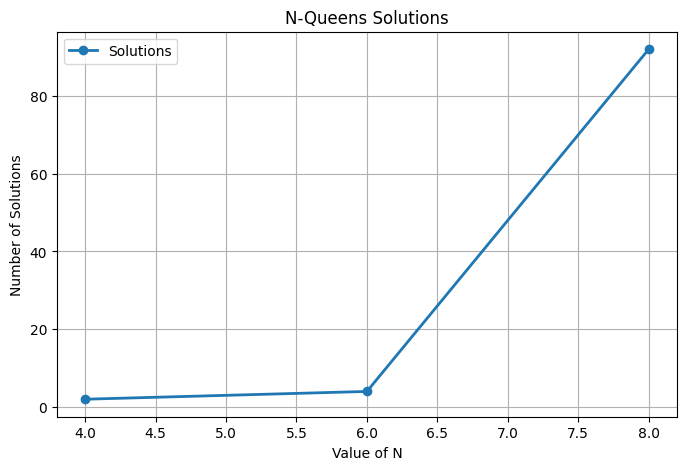

In [1]:
import matplotlib.pyplot as plt

# ---------------- Check Safe Position ----------------
def is_safe(board, row, col):

    for prev_row in range(row):

        placed = board[prev_row]

        # Same column
        if placed == col:
            return False

        # Diagonal
        if abs(prev_row - row) == abs(placed - col):
            return False

    return True


# ---------------- Solve N Queens ----------------
def solve_n_queens(n):

    board = [-1] * n

    solutions = []

    backtracks = [0]

    def backtrack(row):

        if row == n:
            solutions.append(board[:])
            return

        for col in range(n):

            if is_safe(board, row, col):

                board[row] = col

                backtrack(row + 1)

                board[row] = -1

                backtracks[0] += 1

    backtrack(0)

    return solutions, backtracks[0]


# ---------------- Display Board ----------------
def display_board(solution, n):

    print(" +" + "---+" * n)

    for row in range(n):

        print(" |", end="")

        for col in range(n):

            if solution[row] == col:
                print(" Q |", end="")
            else:
                print(" . |", end="")

        print()

        print(" +" + "---+" * n)


# ---------------- Main ----------------

n_values = [4, 6, 8]

solution_count = []
backtrack_count = []

for n in n_values:

    solutions, backtracks = solve_n_queens(n)

    solution_count.append(len(solutions))
    backtrack_count.append(backtracks)

    print(f"\nN = {n}")
    print("Solutions :", len(solutions))
    print("Backtracks :", backtracks)

    if n == 4:

        print("\nAll Solutions\n")

        for i, sol in enumerate(solutions, 1):

            print(f"Solution {i} : {sol}")

            display_board(sol, n)


# ---------------- Graph 1 ----------------

plt.figure(figsize=(8,5))

plt.plot(n_values,
         solution_count,
         marker='o',
         linewidth=2,
         label="Solutions")

plt.title("N-Queens Solutions")
plt.xlabel("Value of N")
plt.ylabel("Number of Solutions")
plt.grid(True)
plt.legend()

plt.show()
